In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

IMG_SIZE = 128

# 1. Create Synthetic Dataset (Images + Masks)
def create_dataset(samples=300):
    images = []
    masks = []

    for _ in range(samples):
        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)

        x = np.random.randint(30, 100)
        y = np.random.randint(30, 100)
        r = np.random.randint(10, 25)

        cv2.circle(img, (x, y), r, (255, 255, 255), -1)
        cv2.circle(mask, (x, y), r, 255, -1)

        images.append(img / 255.0)
        masks.append(mask / 255.0)

    return np.array(images), np.array(masks)

X, y = create_dataset()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [3]:
# 2. Convolution Block
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

In [4]:
# 3. Build U-Net Architecture
inputs = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder
c1 = conv_block(inputs, 32)
p1 = tf.keras.layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = tf.keras.layers.MaxPooling2D()(c2)

c3 = conv_block(p2, 128)
p3 = tf.keras.layers.MaxPooling2D()(c3)

# Bottleneck
bn = conv_block(p3, 256)

# Decoder
u1 = tf.keras.layers.UpSampling2D()(bn)
concat1 = tf.keras.layers.Concatenate()([u1, c3])
c4 = conv_block(concat1, 128)

u2 = tf.keras.layers.UpSampling2D()(c4)
concat2 = tf.keras.layers.Concatenate()([u2, c2])
c5 = conv_block(concat2, 64)

u3 = tf.keras.layers.UpSampling2D()(c5)
concat3 = tf.keras.layers.Concatenate()([u3, c1])
c6 = conv_block(concat3, 32)

outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(c6)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 4. Train Model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=8
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.9528 - loss: 0.2286 - val_accuracy: 0.9972 - val_loss: 0.0068
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 0.9994 - val_loss: 0.0019
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9996 - val_loss: 0.0012
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9993 - loss: 0.0016 - val_accuracy: 0.9996 - val_loss: 0.0014
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9996 - val_loss: 0.0010
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.9997 - loss: 8.9822e-04 - val_accuracy: 0.9997 - val_loss: 7.8897e-04
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.9997 - loss: 8.3597e-04 - val_accuracy: 0.9998 - val_loss: 7.3765e-04
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9998 - loss: 6.9316e-04 - val_accur

In [6]:
# 5. Evaluate Model
loss, acc = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.9997 - loss: 7.2613e-04
Test Loss: 0.0007261256105266511
Test Accuracy: 0.9997223019599915


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step


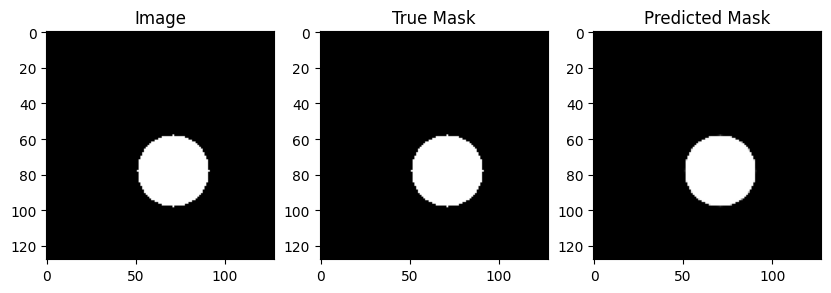

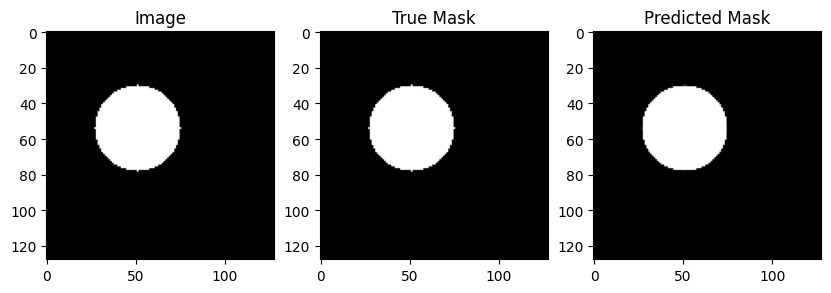

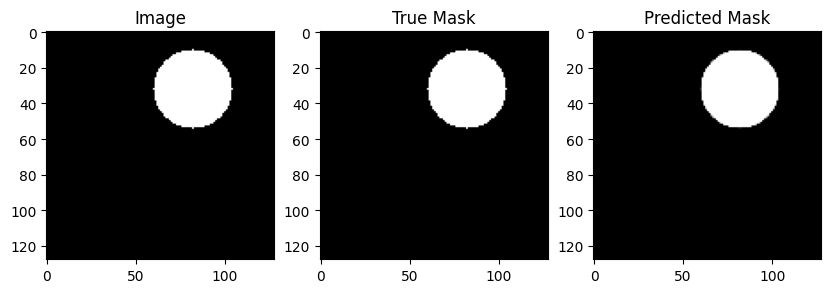

In [7]:
# 6. Predictions
preds = model.predict(X_test[:3])

for i in range(3):
    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(X_test[i])

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(y_test[i].squeeze(), cmap="gray")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(preds[i].squeeze(), cmap="gray")

    plt.show()